# 01 - EDA: Dự đoán trả hàng TMĐT (Online Retail)

## 1. Giới thiệu & Đặt vấn đề

Trong thương mại điện tử, **trả hàng (returns)** là một trong những yếu tố ảnh hưởng mạnh tới chi phí vận hành, trải nghiệm khách hàng và lợi nhuận. Bộ dữ liệu **Online Retail** ghi lại lịch sử giao dịch của một cửa hàng bán lẻ trực tuyến, bao gồm thông tin hóa đơn, sản phẩm, khách hàng và quốc gia.

**Mục tiêu của đề tài**: xây dựng pipeline khai phá dữ liệu để:

- **Dự đoán khả năng một đơn hàng sẽ bị trả lại** (bài toán phân lớp với biến mục tiêu `is_return`).
- **Khai phá luật kết hợp** giữa các sản phẩm thường bị trả cùng nhau, nhằm đưa ra khuyến nghị giúp **giảm tỷ lệ hoàn hàng**.

Notebook **01_eda** tập trung vào việc:

- Khám phá dữ liệu thô (EDA),
- Định nghĩa biến mục tiêu `is_return`,
- Phát hiện các vấn đề về chất lượng dữ liệu (missing, outliers),
- Rút ra các insight ban đầu về hành vi trả hàng.

## 2. Data Dictionary (bản mô tả dữ liệu)

| Cột        | Kiểu      | Mô tả                                                                 |
|-----------|-----------|----------------------------------------------------------------------|
| `InvoiceNo`  | string   | Mã hóa đơn. Bắt đầu bằng số (bán hàng) hoặc chữ `C` (credit note / hủy). |
| `StockCode`  | string   | Mã sản phẩm (SKU) nội bộ.                                           |
| `Description`| string   | Tên/mô tả sản phẩm.                                                 |
| `Quantity`   | int      | Số lượng sản phẩm. **Âm** nếu là giao dịch trả hàng.                |
| `InvoiceDate`| datetime | Thời điểm lập hóa đơn (ngày + giờ).                                |
| `UnitPrice`  | float    | Đơn giá của một đơn vị sản phẩm.                                   |
| `CustomerID` | float/int| Mã khách hàng (ẩn danh), có thể bị thiếu với khách vãng lai.       |
| `Country`    | string   | Quốc gia của khách hàng.                                           |


## 3. Xác định biến mục tiêu & rủi ro mô hình

### 3.1. Định nghĩa biến mục tiêu `is_return`

Trong notebook EDA này, ta định nghĩa sơ bộ biến mục tiêu:

- `is_return = 1` nếu **`Quantity < 0`** (dòng giao dịch là trả hàng/hủy).
- `is_return = 0` nếu **`Quantity >= 0`** (giao dịch bán hàng bình thường).

Lưu ý: Trong pipeline tiền xử lý chính, ta có thể bổ sung thêm quy tắc dựa trên `InvoiceNo` (bắt đầu bằng `C`) để phát hiện credit note.

### 3.2. Mất cân bằng lớp (Class Imbalance)

Trong bối cảnh TMĐT, **số đơn trả hàng thường nhỏ hơn rất nhiều** so với số đơn thành công. Điều này dẫn đến:

- Mô hình dễ nghiêng về việc dự đoán "không trả hàng" (class 0) để đạt accuracy cao nhưng F1 cho lớp trả hàng thấp.
- Cần chú ý sử dụng các metric như **F1-score, ROC-AUC, PR-AUC** và kỹ thuật xử lý mất cân bằng (SMOTE, class weight) trong các bước modeling sau.

### 3.3. Cảnh báo Risk: Data Leakage

Khi xây dựng mô hình dự đoán `is_return`, **tuyệt đối không được sử dụng các biến được sinh ra từ tương lai**, ví dụ:

- Thông tin sau khi khách đã yêu cầu trả hàng (ngày xử lý refund, lý do trả hàng, trạng thái hậu kiểm, v.v.).
- Các biến được tổng hợp trên toàn bộ lịch sử bao gồm cả tương lai so với thời điểm dự đoán.

Trong EDA này, ta chỉ sử dụng **các thuộc tính có sẵn tại thời điểm lập hóa đơn** (InvoiceDate, UnitPrice, Quantity, sản phẩm, khách hàng, quốc gia) để đảm bảo không gây **rò rỉ thông tin (data leakage)** cho mô hình sau này.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

# Đọc dữ liệu thô từ file CSV gốc
DATA_PATH = Path("../data/raw/data.csv")
df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    parse_dates=["InvoiceDate"],
    dtype={"InvoiceNo": str, "StockCode": str},
)

# Định nghĩa biến mục tiêu is_return dựa trên Quantity < 0
df["is_return"] = (df["Quantity"] < 0).astype(int)

print(f"Số dòng: {len(df):,}")
print("\n5 dòng đầu tiên:")
display(df.head())


Số dòng: 541,909

5 dòng đầu tiên:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0


C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_10484\2521980172.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax[0], palette=["tab:blue", "tab:red"])


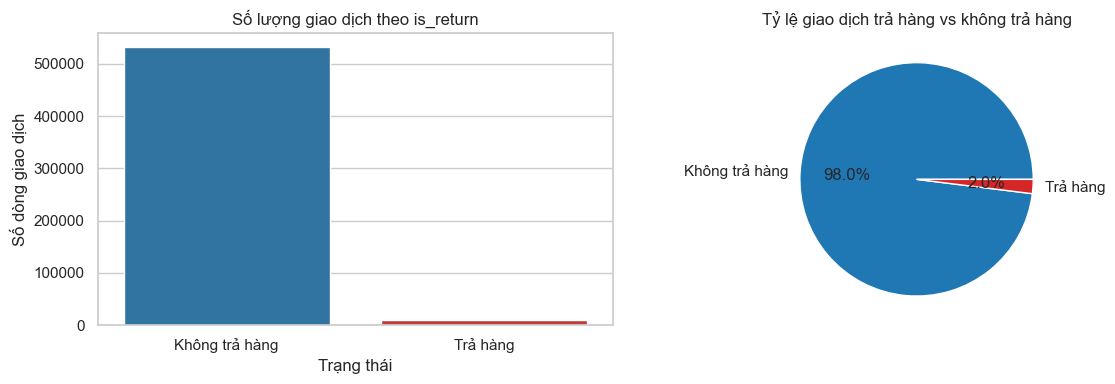

In [2]:
# Biểu đồ 1: Tỷ lệ target is_return (Class Imbalance)
target_counts = df["is_return"].value_counts().rename(index={0: "Không trả hàng", 1: "Trả hàng"})
target_ratio = target_counts / target_counts.sum()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ cột
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax[0], palette=["tab:blue", "tab:red"])
ax[0].set_title("Số lượng giao dịch theo is_return")
ax[0].set_ylabel("Số dòng giao dịch")
ax[0].set_xlabel("Trạng thái")

# Biểu đồ tròn
ax[1].pie(target_ratio.values, labels=target_ratio.index, autopct="%1.1f%%", colors=["tab:blue", "tab:red"])
ax[1].set_title("Tỷ lệ giao dịch trả hàng vs không trả hàng")

plt.tight_layout()
plt.show()


### Insight 1: Mức độ mất cân bằng lớp

Biểu đồ cho thấy **số lượng giao dịch không trả hàng chiếm đa số tuyệt đối**, trong khi các dòng giao dịch có `is_return = 1` (trả hàng) chiếm một tỷ lệ nhỏ. Điều này xác nhận **bài toán phân lớp bị mất cân bằng lớp**:

- Nếu chỉ tối ưu accuracy, mô hình có thể "lười" dự đoán trả hàng và chỉ chọn lớp 0.
- Các metric nhạy với lớp thiểu số (F1 cho lớp 1, PR-AUC, ROC-AUC) và kỹ thuật xử lý imbalance sẽ rất quan trọng ở các bước modeling tiếp theo.


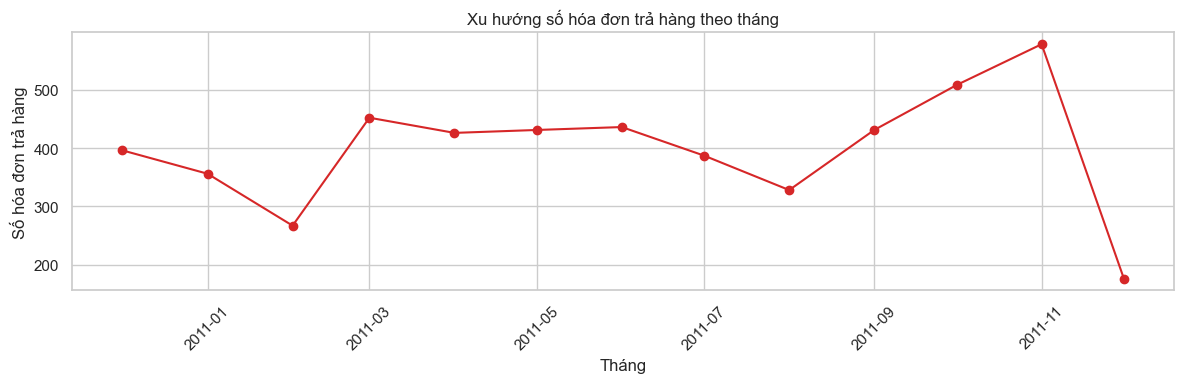

In [3]:
# Biểu đồ 2: Xu hướng thời gian của giao dịch trả hàng theo tháng

# Tạo cột tháng từ InvoiceDate
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

monthly_returns = (
    df[df["is_return"] == 1]
    .groupby("InvoiceMonth")["InvoiceNo"]
    .nunique()
    .rename("num_return_invoices")
)

plt.figure(figsize=(12, 4))
plt.plot(monthly_returns.index, monthly_returns.values, marker="o", color="tab:red")
plt.title("Xu hướng số hóa đơn trả hàng theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Số hóa đơn trả hàng")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Insight 2: Chu kỳ trả hàng theo thời gian

Đường xu hướng cho thấy **số lượng hóa đơn trả hàng thay đổi theo tháng**, thường có những giai đoạn đỉnh điểm (ví dụ các tháng cao điểm mua sắm) và giai đoạn thấp hơn:

- Nếu các đỉnh rơi vào dịp lễ/tết hoặc mùa khuyến mại, có thể liên quan đến **mua sắm cảm tính** dẫn đến trả hàng nhiều hơn.
- Thông tin này hữu ích để kết hợp với mô hình dự báo chuỗi thời gian (ARIMA/Prophet) nhằm **dự báo tỷ lệ trả hàng theo tháng** và điều chỉnh tồn kho/chính sách chăm sóc khách hàng.


C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_10484\2673172199.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


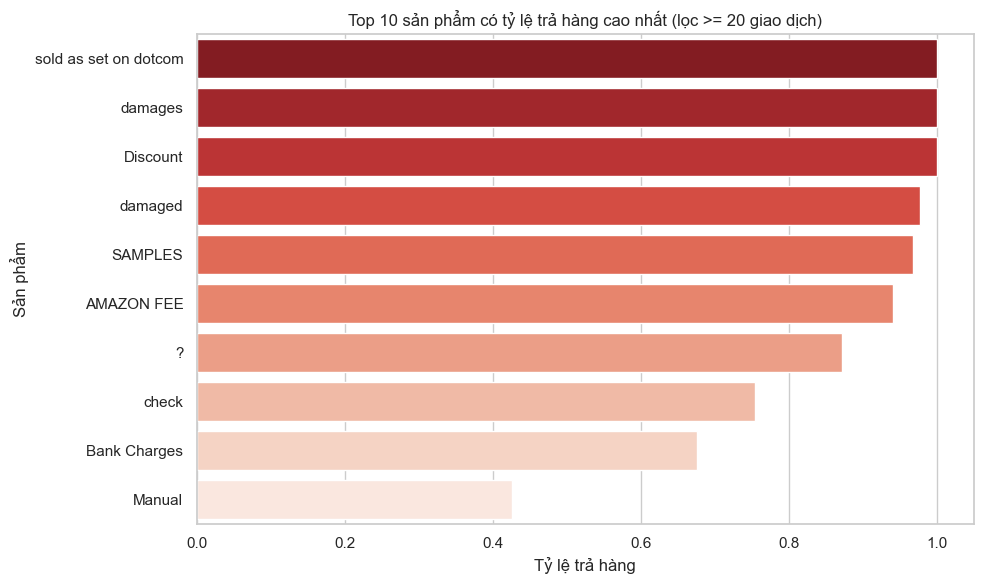

,Description,return_rate,n_transactions
0,sold as set on dotcom,1.000000,20
1,damages,1.000000,45
2,Discount,1.000000,77
3,damaged,0.976744,43
4,SAMPLES,0.968254,63


In [4]:
# Biểu đồ 3: Top 10 sản phẩm có tỷ lệ trả hàng cao nhất

# Tính tỷ lệ trả hàng theo sản phẩm (Description)
product_stats = (
    df.groupby("Description")["is_return"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "return_rate", "count": "n_transactions"})
)

# Lọc các sản phẩm có đủ số lượng giao dịch tối thiểu để tỷ lệ ổn định hơn
min_transactions = 20
product_stats_filtered = product_stats[product_stats["n_transactions"] >= min_transactions]

top_risky_products = (
    product_stats_filtered.sort_values("return_rate", ascending=False).head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_risky_products.reset_index(),
    y="Description",
    x="return_rate",
    palette="Reds_r",
)
plt.title("Top 10 sản phẩm có tỷ lệ trả hàng cao nhất (lọc >= 20 giao dịch)")
plt.xlabel("Tỷ lệ trả hàng")
plt.ylabel("Sản phẩm")
plt.tight_layout()
plt.show()

top_risky_products.reset_index().head()

### Insight 3: Nhóm sản phẩm rủi ro cao

Biểu đồ cho thấy tồn tại một số **sản phẩm có tỷ lệ trả hàng đặc biệt cao** (sau khi đã lọc các sản phẩm có đủ số lượng giao dịch để tránh nhiễu):

- Đây là **ứng viên ưu tiên** để đội vận hành kiểm tra lại: mô tả trên website, chất lượng thực tế, hình ảnh minh họa, hướng dẫn sử dụng, đóng gói, v.v.
- Nếu nhiều sản phẩm trong Top rủi ro thuộc cùng một nhóm (ví dụ cùng danh mục, cùng nhà cung cấp), có thể tồn tại **vấn đề hệ thống** (chất lượng lô hàng, sai lệch thông số, kỳ vọng khách hàng không khớp).
- Các sản phẩm này cũng nên được gán trọng số rủi ro cao hơn trong các mô hình scoring/khuyến nghị sau này.


=== Số lượng giá trị thiếu (null) ở các cột chính ===


,num_null
CustomerID,135080
Description,1454



=== Thống kê mô tả UnitPrice ===


count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


Số dòng có UnitPrice <= 0: 2,517


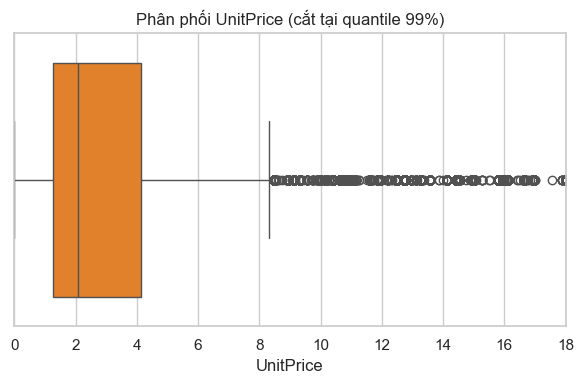

In [5]:
# 4. Kiểm tra chất lượng dữ liệu

print("=== Số lượng giá trị thiếu (null) ở các cột chính ===")
missing_counts = df[["CustomerID", "Description"]].isna().sum()
display(missing_counts.to_frame(name="num_null"))

print("\n=== Thống kê mô tả UnitPrice ===")
display(df["UnitPrice"].describe())

# Kiểm tra các giá trị UnitPrice bất thường (<= 0)
num_zero_price = (df["UnitPrice"] <= 0).sum()
print(f"\nSố dòng có UnitPrice <= 0: {num_zero_price:,}")

# Boxplot UnitPrice (cắt ngưỡng 99% để nhìn rõ hơn)
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["UnitPrice"], color="tab:orange")
plt.xlim(0, df["UnitPrice"].quantile(0.99))
plt.title("Phân phối UnitPrice (cắt tại quantile 99%)")
plt.xlabel("UnitPrice")
plt.tight_layout()
plt.show()


### Insight 4: Chất lượng dữ liệu & tiền xử lý cần thiết

Từ bảng thống kê và biểu đồ kiểm tra chất lượng dữ liệu, ta quan sát được:

- **CustomerID bị thiếu khá nhiều** (khách vãng lai hoặc chưa được gán mã). Cần quyết định chiến lược: loại bỏ, gán nhãn chung (`Guest_Unknown`), hoặc xử lý riêng cho từng bài toán (RFM, phân cụm khách hàng).
- **Description đôi khi bị thiếu hoặc không đồng nhất** (viết hoa/thường, khoảng trắng thừa), cần chuẩn hóa/điền giá trị mặc định cho các bước khai phá luật kết hợp.
- Tồn tại một số dòng có **UnitPrice = 0 hoặc giá bất thường rất cao**; đây là outlier cần được xử lý (loại bỏ hoặc winsorize) trước khi tính doanh thu, RFM, hay huấn luyện mô hình.

Những phát hiện này sẽ được xử lý có hệ thống trong **pipeline tiền xử lý (`DataCleaner`)** và các bước feature engineering tiếp theo.
